# DDPM training-set evaluation and visualization

Use this notebook to evaluate a selected DDPM deconvolution or super-resolution + deconvolution model on a selected training dataset.

Evaluation is split into two spaces:

1. **Normalized model space**: compares tensors in the `[0, 1]` or `[-1, 1]` space used during training. SSIM, MS-SSIM, and PSNR are reported here.
2. **Counts/application space**: restores DDPM outputs to a counts-map-like scale and uses physically useful metrics: count-normalized errors, flux error, peak/centroid displacement, Poisson deviance, and reduced chi-square. Raw-count PSNR/SSIM are intentionally not used.

Enhanced plots use restored counts maps so the display logic matches `data/GT_conv_check.ipynb` instead of visualizing per-image normalized tensors.


In [1]:
from pathlib import Path
import csv
import importlib
import json
import math
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn.functional as F
from matplotlib.colors import PowerNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.ndimage import map_coordinates
from torchmetrics.image import MultiScaleStructuralSimilarityIndexMeasure as MS_SSIM
from torchmetrics.image import PeakSignalNoiseRatio as PSNR
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from tqdm.auto import tqdm

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "codes").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing both codes/ and data/.")


ADDR_ROOT = find_repo_root()
ADDR_CODE = ADDR_ROOT / "codes"
ADDR_MODELS = ADDR_CODE / "models"
for path in [ADDR_ROOT, ADDR_CODE, ADDR_MODELS]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.append(path_str)

from codes.config.config_DDPM import ModelConfig

print(f"ADDR_ROOT = {ADDR_ROOT}")
print(f"ADDR_CODE = {ADDR_CODE}")
print(f"CUDA available = {torch.cuda.is_available()}")


ADDR_ROOT = /root/LHAI_KM2A
ADDR_CODE = /root/LHAI_KM2A/codes
CUDA available = True


/root/miniconda3/envs/LHAI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RUN_LABEL = "TRAIN"

DATA_DIR = ADDR_ROOT / "data" / "Train"
DATA_NAME = "SR4poissonexcess_4800_64_KM2A.npy"

MODEL_WEIGHT_DIR = ADDR_ROOT / "saves" / "MODEL" / "DDPM"
MODEL_WEIGHT_NAME = "Last_DDPM_KM2AE25_400epo_64bth_KM2A4poisonexcess.pth"

DIFFUSION_CONFIG_KEY = "DDPM_64"
DIFFUSION_MODULE_NAME = "DDPM"
DIFFUSION_CLASS_NAME = "DDPM"

UNET_CONFIG_KEY = "UNET"
UNET_MODULE_NAME = "UNET"
UNET_CLASS_NAME = "UNET"

DATA_RANGE = 2.0
COUNTS_RESTORE_MODE_FOR_METRICS = "input_mass_match"
COUNTS_RESTORE_MODE_FOR_VISUAL = "input_mass_match"
CLIP_FOR_COUNTS = True
EPS_COUNTS = 1e-8

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
STRICT_LOAD = True
CLAMP_OUTPUT = False
OVERRIDE_IMG_SIZE_FROM_DATA = True

EVAL_INDICES = None
EVAL_START = 0
EVAL_STOP = 199
EVAL_STEP = 1
INFERENCE_BATCH_SIZE = 200
SAMPLING_SEED = 0

# VIS_INDICES = [2063,2139]
VIS_INDICES = [0,4,8,12,16,20,24,28,32,36,40,44,48,52,56,60]
LINE_SEGMENTS = {}

SAVE_OUTPUTS = True
OUTPUT_DIR = ADDR_ROOT / "saves" / "EVAL" / "DDPM" / RUN_LABEL


In [3]:
TRAIN_DATASET_NAMES = [
    "SR4bkgon_3198_64_train.npy",
    "SR4bkgon_3198_128_train.npy",
    "SR4excess_3198_64_train.npy",
    "SR4excess_3198_128_train.npy",
    "SR4poisonon_3198_64_train.npy",
    "SR4poisonon_3198_128_train.npy",
]


def show_available_files():
    data_files = sorted(DATA_DIR.glob("*.npy")) if DATA_DIR.exists() else []
    weight_files = sorted(MODEL_WEIGHT_DIR.glob("*.pth")) if MODEL_WEIGHT_DIR.exists() else []
    print("Available data files:")
    for path in data_files:
        print(f"  {path.name}")
    if not data_files:
        print(f"  No .npy files found in {DATA_DIR}")
    print("\nAvailable DDPM weights:")
    for path in weight_files:
        print(f"  {path.name}")
    if not weight_files:
        print(f"  No .pth files found in {MODEL_WEIGHT_DIR}")
    print("\nConfig hints:")
    print("  64x64 deconvolution: DIFFUSION_CONFIG_KEY = 'DDPM_64'")
    print("  128x128 SR+deconvolution: DIFFUSION_CONFIG_KEY = 'DDPM128'")


show_available_files()

if DATA_NAME is None:
    raise ValueError("Set DATA_NAME in the configuration cell, then rerun from this cell.")
if MODEL_WEIGHT_NAME is None:
    raise ValueError("Set MODEL_WEIGHT_NAME in the configuration cell, then rerun from this cell.")

data_path = DATA_DIR / DATA_NAME
model_weight_path = MODEL_WEIGHT_DIR / MODEL_WEIGHT_NAME
if not data_path.exists():
    raise FileNotFoundError(data_path)
if not model_weight_path.exists():
    raise FileNotFoundError(model_weight_path)

print(f"Selected data: {data_path}")
print(f"Selected weight: {model_weight_path}")


Available data files:
  KM2A4bkgon_3200_64_train.npy
  KM2A4eval_7250_64_train.npy
  KM2A4excess_3200_64_train.npy
  KM2A4poisonexcess_19200_64_trainE25.npy
  KM2A4poisonexcess_19200_64_trainE25_v2.npy
  KM2A4poisonon_3200_64_train.npy
  SR4poissonexcess_4800_64_KM2A.npy
  SR4poissonon_4800_64_KM2A.npy

Available DDPM weights:
  Best_DDPM_EXP01_2epo_32bth_SR4poissonexcess.pth
  Best_DDPM_EXP01_400epo_128bth_KM2A4eval.pth
  Best_DDPM_KM2AE25_100epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2AE25_2epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2AE25_400epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2AE25v2_600epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2A_1000epo_32bth_SR4poissonexcess.pth
  Best_DDPM_KM2A_400epo_32bth_SR4poissonexcess.pth
  Best_DDPM_KM2A_400epo_32bth_SR4poissonexcess_finetuned.pth
  Best_DDPM_KM2A_400epo_32bth_SR4poissonexcess_finetuned400epo.pth
  Best_DDPM_KM2A_400epo_32bth_SR4poissonexcess_finetuned600epo.pth

In [4]:
def _ensure_nchw(images):
    images = np.asarray(images)
    if images.ndim == 3:
        images = images[:, None, :, :]
    if images.ndim == 4:
        return images.astype(np.float32, copy=False)
    raise ValueError(f"Expected image array with shape (N,H,W) or (N,C,H,W), got {images.shape}")


def load_pair_arrays(path):
    data = np.load(path, allow_pickle=True)
    if data.ndim >= 4 and data.shape[1] >= 2:
        targets = np.stack(data[:, 0])
        inputs = np.stack(data[:, 1])
    elif data.ndim == 2 and data.shape[1] >= 2:
        targets = np.stack(data[:, 0])
        inputs = np.stack(data[:, 1])
    else:
        raise ValueError(
            "Expected paired dataset where data[:,0] is GT/target and data[:,1] is input/response. "
            f"Got shape {data.shape}."
        )
    return _ensure_nchw(inputs), _ensure_nchw(targets)


def minmax_stats_per_image(images):
    flat = images.reshape(images.shape[0], -1)
    mins = flat.min(axis=1).reshape((-1, 1, 1, 1)).astype(np.float32)
    maxs = flat.max(axis=1).reshape((-1, 1, 1, 1)).astype(np.float32)
    return mins, maxs


def normalize_from_stats(images, mins, maxs, data_range=1.0):
    norm01 = (images.astype(np.float32, copy=False) - mins) / np.maximum(maxs - mins, 1e-8)
    if abs(data_range - 1.0) < 1e-6:
        return norm01.astype(np.float32, copy=False)
    if abs(data_range - 2.0) < 1e-6:
        return (2.0 * norm01 - 1.0).astype(np.float32, copy=False)
    raise ValueError("DATA_RANGE must be 1.0 or 2.0")


def resize_numpy_batch(batch, size):
    batch = np.asarray(batch, dtype=np.float32)
    if batch.shape[-2:] == (size, size):
        return batch
    tensor = torch.from_numpy(batch).float()
    return F.interpolate(tensor, size=(size, size), mode="bilinear", align_corners=False).numpy()


raw_inputs_np, raw_targets_np = load_pair_arrays(data_path)
input_mins, input_maxs = minmax_stats_per_image(raw_inputs_np)
target_mins, target_maxs = minmax_stats_per_image(raw_targets_np)
inputs_np = normalize_from_stats(raw_inputs_np, input_mins, input_maxs, DATA_RANGE)
targets_np = normalize_from_stats(raw_targets_np, target_mins, target_maxs, DATA_RANGE)

if inputs_np.shape[0] != targets_np.shape[0]:
    raise ValueError("Input/target sample counts differ.")
if inputs_np.shape[1] != targets_np.shape[1]:
    raise ValueError("Input/target channel counts differ.")

print(f"raw input shape  = {raw_inputs_np.shape}")
print(f"raw target shape = {raw_targets_np.shape}")
print(f"raw input range  = ({raw_inputs_np.min():.4g}, {raw_inputs_np.max():.4g})")
print(f"raw target range = ({raw_targets_np.min():.4g}, {raw_targets_np.max():.4g})")
print(f"model input shape  = {inputs_np.shape}, range=({inputs_np.min():.4g}, {inputs_np.max():.4g})")
print(f"model target shape = {targets_np.shape}, range=({targets_np.min():.4g}, {targets_np.max():.4g})")


raw input shape  = (4800, 1, 64, 64)
raw target shape = (4800, 1, 64, 64)
raw input range  = (-10.12, 402)
raw target range = (0, 178.1)
model input shape  = (4800, 1, 64, 64), range=(-1, 1)
model target shape = (4800, 1, 64, 64), range=(-1, 1)


In [5]:
def import_model_class(module_name, class_name):
    module = importlib.import_module(f"codes.models.{module_name}")
    return getattr(module, class_name)


model_cfg = ModelConfig()
model_params = model_cfg.model_params
image_size = int(targets_np.shape[-1])
if targets_np.shape[-1] != targets_np.shape[-2]:
    raise ValueError(f"Target images must be square for current DDPM implementation, got {targets_np.shape[-2:]}")

if DIFFUSION_CONFIG_KEY is None:
    if image_size == 128 and "DDPM128" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM128"
    elif image_size == 64 and "DDPM_64" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM_64"
    elif "DDPM" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM"
    else:
        raise KeyError("Could not infer DIFFUSION_CONFIG_KEY. Set it manually.")

if DIFFUSION_CONFIG_KEY not in model_params:
    raise KeyError(f"{DIFFUSION_CONFIG_KEY=} not found in ModelConfig.model_params")
if UNET_CONFIG_KEY not in model_params:
    raise KeyError(f"{UNET_CONFIG_KEY=} not found in ModelConfig.model_params")

params_diffusion = dict(model_params[DIFFUSION_CONFIG_KEY])
params_unet = dict(model_params[UNET_CONFIG_KEY])
if OVERRIDE_IMG_SIZE_FROM_DATA and params_diffusion.get("img_size") != image_size:
    print(f"Overriding diffusion img_size from {params_diffusion.get('img_size')} to data target size {image_size}.")
    params_diffusion["img_size"] = image_size
params_diffusion["device"] = torch.device(DEVICE)

torch.manual_seed(SAMPLING_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SAMPLING_SEED)

device = torch.device(DEVICE)
DIFFUSION = import_model_class(DIFFUSION_MODULE_NAME, DIFFUSION_CLASS_NAME)
UNET = import_model_class(UNET_MODULE_NAME, UNET_CLASS_NAME)

diffusion = DIFFUSION(**params_diffusion)
unet = UNET(**params_unet).to(device)
if hasattr(unet, "build"):
    unet.build()
unet.to(device)
state = torch.load(model_weight_path, map_location=device)
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
unet.load_state_dict(state, strict=STRICT_LOAD)
unet.eval()

print(f"Device: {device}")
print(f"Diffusion config key: {DIFFUSION_CONFIG_KEY}")
print(f"Diffusion class: {DIFFUSION_MODULE_NAME}.{DIFFUSION_CLASS_NAME}")
print(f"UNET config/class: {UNET_CONFIG_KEY} / {UNET_MODULE_NAME}.{UNET_CLASS_NAME}")
print(f"Image size: {image_size}")


Device: cuda
Diffusion config key: DDPM_64
Diffusion class: DDPM.DDPM
UNET config/class: UNET / UNET.UNET
Image size: 64


In [6]:
def select_eval_indices(total, explicit=None, start=0, stop=None, step=1):
    if explicit is not None:
        indices = np.asarray(explicit, dtype=int)
    else:
        stop = total if stop is None else min(int(stop), total)
        indices = np.arange(int(start), stop, int(step), dtype=int)
    if indices.size == 0:
        raise ValueError("No evaluation indices selected.")
    if indices.min() < 0 or indices.max() >= total:
        raise IndexError(f"Selected indices must be in [0, {total - 1}], got {indices.min()}..{indices.max()}.")
    return indices


def tensor_from_numpy_batch(array, indices):
    return torch.from_numpy(array[indices]).float()


def resize_to_model_size(batch):
    if batch.shape[-2:] == (image_size, image_size):
        return batch
    return F.interpolate(batch, size=(image_size, image_size), mode="bilinear", align_corners=False)


def maybe_clamp(batch):
    if not CLAMP_OUTPUT:
        return batch
    if abs(DATA_RANGE - 1.0) < 1e-6:
        return batch.clamp(0.0, 1.0)
    return batch.clamp(-1.0, 1.0)


def reduce_generated(generated, batch_size):
    if generated.dim() == 5:
        if generated.shape[0] == batch_size:
            generated = generated[:, -1]
        else:
            generated = generated[-1]
    return maybe_clamp(generated)


@torch.no_grad()
def generate_batch(input_batch):
    input_batch = resize_to_model_size(input_batch.to(device))
    torch.manual_seed(SAMPLING_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SAMPLING_SEED)
    generated = diffusion.reverse_diffusion(
        model=unet,
        n_images=input_batch.shape[0],
        n_channels=input_batch.shape[1],
        input_image=input_batch,
        save_time_steps=None,
    )
    return reduce_generated(generated, input_batch.shape[0])


def normalized_to_unit_interval(array):
    array = np.asarray(array, dtype=np.float32)
    if abs(DATA_RANGE - 2.0) < 1e-6:
        unit = 0.5 * (array + 1.0)
    elif abs(DATA_RANGE - 1.0) < 1e-6:
        unit = array
    else:
        raise ValueError("DATA_RANGE must be 1.0 or 2.0")
    return np.clip(unit, 0.0, 1.0) if CLIP_FOR_COUNTS else unit


def _stats_for_indices(mins, maxs, indices):
    return mins[indices], maxs[indices]


def _minmax_restore(norm_batch, mins, maxs):
    unit = normalized_to_unit_interval(norm_batch)
    return unit * np.maximum(maxs - mins, EPS_COUNTS) + mins


def _mass_match_restore(norm_batch, reference_counts):
    unit = np.clip(normalized_to_unit_interval(norm_batch), 0.0, None)
    reference = np.clip(reference_counts.astype(np.float32, copy=False), 0.0, None)
    unit_mass = unit.reshape(unit.shape[0], -1).sum(axis=1).reshape((-1, 1, 1, 1))
    reference_mass = reference.reshape(reference.shape[0], -1).sum(axis=1).reshape((-1, 1, 1, 1))
    return unit * (reference_mass / np.maximum(unit_mass, EPS_COUNTS))


def restore_generated_counts(norm_batch, indices, mode):
    norm_batch = np.asarray(norm_batch, dtype=np.float32)
    indices = np.asarray(indices, dtype=int)
    if mode == "target_minmax":
        mins, maxs = _stats_for_indices(target_mins, target_maxs, indices)
        return _minmax_restore(norm_batch, mins, maxs)
    if mode == "input_minmax":
        mins, maxs = _stats_for_indices(input_mins, input_maxs, indices)
        return _minmax_restore(norm_batch, mins, maxs)
    if mode == "target_mass_match":
        return _mass_match_restore(norm_batch, raw_target_counts(indices))
    if mode == "input_mass_match":
        return _mass_match_restore(norm_batch, raw_input_counts(indices))
    raise ValueError("Restore mode must be one of: target_minmax, input_minmax, target_mass_match, input_mass_match")


def raw_input_counts(indices):
    return resize_numpy_batch(raw_inputs_np[np.asarray(indices, dtype=int)], image_size)


def raw_target_counts(indices):
    return resize_numpy_batch(raw_targets_np[np.asarray(indices, dtype=int)], image_size)


def safe_metric(metric, pred, target):
    try:
        return float(metric(pred, target).detach().cpu().item())
    except Exception as exc:
        print(f"Metric {metric.__class__.__name__} failed for one image: {exc}")
        return float("nan")


def positive_mass(array):
    return float(np.clip(np.asarray(array, dtype=np.float64), 0.0, None).sum())


def pearson_corr(pred, target):
    pred = np.asarray(pred).reshape(-1).astype(np.float64)
    target = np.asarray(target).reshape(-1).astype(np.float64)
    if np.std(pred) < 1e-12 or np.std(target) < 1e-12:
        return float("nan")
    return float(np.corrcoef(pred, target)[0, 1])


def peak_distance(pred, target):
    pred = np.asarray(pred)
    target = np.asarray(target)
    pred_yx = np.unravel_index(int(np.nanargmax(pred)), pred.shape)
    target_yx = np.unravel_index(int(np.nanargmax(target)), target.shape)
    return float(np.hypot(pred_yx[0] - target_yx[0], pred_yx[1] - target_yx[1]))


def weighted_centroid(image):
    image = np.clip(np.asarray(image, dtype=np.float64), 0.0, None)
    total = image.sum()
    if total <= EPS_COUNTS:
        return np.array([np.nan, np.nan], dtype=np.float64)
    yy, xx = np.indices(image.shape)
    return np.array([(yy * image).sum() / total, (xx * image).sum() / total], dtype=np.float64)


def centroid_distance(pred, target):
    pred_c = weighted_centroid(pred)
    target_c = weighted_centroid(target)
    if np.any(~np.isfinite(pred_c)) or np.any(~np.isfinite(target_c)):
        return float("nan")
    return float(np.linalg.norm(pred_c - target_c))


def poisson_deviance_per_pixel(pred, target):
    pred = np.clip(np.asarray(pred, dtype=np.float64), EPS_COUNTS, None)
    target = np.clip(np.asarray(target, dtype=np.float64), 0.0, None)
    term = pred - target
    mask = target > 0
    term[mask] += target[mask] * np.log(target[mask] / pred[mask])
    return float(2.0 * np.sum(term) / target.size)


def reduced_chi_square(pred, target):
    pred = np.clip(np.asarray(pred, dtype=np.float64), 0.0, None)
    target = np.clip(np.asarray(target, dtype=np.float64), 0.0, None)
    return float(np.mean((pred - target) ** 2 / np.maximum(target, 1.0)))


def image_metrics_normalized(pred, target, source, image_index, ms_ssim_metric, ssim_metric, psnr_metric):
    pred = pred.unsqueeze(0).to(device)
    target = target.unsqueeze(0).to(device)
    diff = pred - target
    rmse = torch.sqrt(torch.mean(diff ** 2)).item()
    target_range = (target.max() - target.min()).clamp(min=1e-8).item()
    mae = torch.mean(torch.abs(diff)).item()
    pred_np = pred.squeeze().detach().cpu().numpy()
    target_np = target.squeeze().detach().cpu().numpy()
    return {
        "image_index": int(image_index),
        "source": source,
        "NRMSE": float(rmse / target_range),
        "RMSE": float(rmse),
        "MAE": float(mae),
        "MS-SSIM": safe_metric(ms_ssim_metric, pred, target),
        "SSIM": safe_metric(ssim_metric, pred, target),
        "PSNR": safe_metric(psnr_metric, pred, target),
        "Pearson": pearson_corr(pred_np, target_np),
        "PeakDistancePx": peak_distance(pred_np, target_np),
    }


def image_metrics_counts(pred, target, source, image_index):
    pred = np.asarray(pred, dtype=np.float64).squeeze()
    target = np.asarray(target, dtype=np.float64).squeeze()
    diff = pred - target
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mae = float(np.mean(np.abs(diff)))
    abs_target_sum = float(np.sum(np.abs(target)))
    target_positive_sum = positive_mass(target)
    pred_positive_sum = positive_mass(pred)
    return {
        "image_index": int(image_index),
        "source": source,
        "CountMAE": mae,
        "CountRMSE": rmse,
        "CountNMAE": float(np.sum(np.abs(diff)) / (abs_target_sum + EPS_COUNTS)),
        "CountNRMSEMean": float(rmse / (np.mean(np.abs(target)) + EPS_COUNTS)),
        "FluxRelErr": float((pred_positive_sum - target_positive_sum) / (abs(target_positive_sum) + EPS_COUNTS)),
        "AbsFluxRelErr": float(abs(pred_positive_sum - target_positive_sum) / (abs(target_positive_sum) + EPS_COUNTS)),
        "Pearson": pearson_corr(pred, target),
        "PeakDistancePx": peak_distance(pred, target),
        "CentroidDistancePx": centroid_distance(pred, target),
        "PoissonDeviancePerPixel": poisson_deviance_per_pixel(pred, target),
        "ReducedChiSquare": reduced_chi_square(pred, target),
    }


def run_evaluations(indices):
    ms_ssim_metric = MS_SSIM(data_range=DATA_RANGE, kernel_size=7, betas=(0.0448, 0.2856, 0.3001)).to(device)
    ssim_metric = SSIM(data_range=DATA_RANGE).to(device)
    psnr_metric = PSNR(data_range=DATA_RANGE).to(device)
    normalized_rows = []
    counts_rows = []
    generated_cache = {}
    for batch_start in tqdm(range(0, len(indices), INFERENCE_BATCH_SIZE), desc="DDPM evaluation batches"):
        batch_indices = indices[batch_start : batch_start + INFERENCE_BATCH_SIZE]
        inputs = tensor_from_numpy_batch(inputs_np, batch_indices)
        targets = tensor_from_numpy_batch(targets_np, batch_indices)
        inputs_model = resize_to_model_size(inputs).to(device)
        targets_model = resize_to_model_size(targets).to(device)
        generated = generate_batch(inputs)
        generated_np = generated.detach().cpu().numpy()
        input_counts = raw_input_counts(batch_indices)
        target_counts = raw_target_counts(batch_indices)
        generated_counts = restore_generated_counts(generated_np, batch_indices, COUNTS_RESTORE_MODE_FOR_METRICS)
        for local_i, image_index in enumerate(batch_indices):
            image_index = int(image_index)
            normalized_rows.append(image_metrics_normalized(inputs_model[local_i], targets_model[local_i], "input", image_index, ms_ssim_metric, ssim_metric, psnr_metric))
            normalized_rows.append(image_metrics_normalized(generated[local_i], targets_model[local_i], "generated", image_index, ms_ssim_metric, ssim_metric, psnr_metric))
            counts_rows.append(image_metrics_counts(input_counts[local_i], target_counts[local_i], "input", image_index))
            counts_rows.append(image_metrics_counts(generated_counts[local_i], target_counts[local_i], "generated", image_index))
            generated_cache[image_index] = generated_np[local_i]
        del inputs, targets, inputs_model, targets_model, generated
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return normalized_rows, counts_rows, generated_cache


def summarize_rows(rows):
    metrics = [k for k in rows[0].keys() if k not in {"image_index", "source"}]
    summary = {}
    for source in sorted({row["source"] for row in rows}):
        source_rows = [row for row in rows if row["source"] == source]
        summary[source] = {}
        for metric in metrics:
            values = np.asarray([row[metric] for row in source_rows], dtype=np.float64)
            summary[source][metric] = {"mean": float(np.nanmean(values)), "std": float(np.nanstd(values))}
    return summary


def print_normalized_summary(summary, n_images):
    for source in ["generated", "input"]:
        if source not in summary:
            continue
        print(f"\n=== Normalized-space metrics on {n_images} {source} images ===")
        for metric in ["NRMSE", "MAE", "MS-SSIM", "SSIM", "PSNR", "Pearson", "PeakDistancePx"]:
            value = summary[source][metric]["mean"]
            std = summary[source][metric]["std"]
            print(f"{metric:<18} {value: .6f}  +/- {std:.6f}")


def print_counts_summary(summary, n_images):
    print(f"\nCounts restore mode for generated outputs: {COUNTS_RESTORE_MODE_FOR_METRICS}")
    for source in ["generated", "input"]:
        if source not in summary:
            continue
        print(f"\n=== Counts-space/application metrics on {n_images} {source} images ===")
        for metric in ["CountNMAE", "CountNRMSEMean", "AbsFluxRelErr", "FluxRelErr", "Pearson", "PeakDistancePx", "CentroidDistancePx", "PoissonDeviancePerPixel", "ReducedChiSquare"]:
            value = summary[source][metric]["mean"]
            std = summary[source][metric]["std"]
            print(f"{metric:<24} {value: .6f}  +/- {std:.6f}")


def save_evaluation_outputs(normalized_rows, counts_rows, normalized_summary, counts_summary, indices):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    stem = f"{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}__{indices[0]}_{indices[-1]}"
    norm_csv_path = OUTPUT_DIR / f"normalized_metrics_per_image__{stem}.csv"
    counts_csv_path = OUTPUT_DIR / f"counts_metrics_per_image__{stem}.csv"
    summary_path = OUTPUT_DIR / f"metrics_summary__{stem}.json"
    for path, rows in [(norm_csv_path, normalized_rows), (counts_csv_path, counts_rows)]:
        with path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
            writer.writeheader()
            writer.writerows(rows)
        print(f"Saved metrics: {path}")
    payload = {
        "run_label": RUN_LABEL,
        "data_path": str(data_path),
        "model_weight_path": str(model_weight_path),
        "diffusion_config_key": DIFFUSION_CONFIG_KEY,
        "unet_config_key": UNET_CONFIG_KEY,
        "data_range": DATA_RANGE,
        "counts_restore_mode_for_metrics": COUNTS_RESTORE_MODE_FOR_METRICS,
        "counts_restore_mode_for_visual": COUNTS_RESTORE_MODE_FOR_VISUAL,
        "indices": [int(i) for i in indices],
        "normalized_summary": normalized_summary,
        "counts_summary": counts_summary,
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }
    summary_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Saved summary: {summary_path}")


def plot_metric_curves(rows, indices, metrics, title, filename_prefix):
    by_source = {source: [row for row in rows if row["source"] == source] for source in ["input", "generated"]}
    cols = 3
    rows_n = math.ceil(len(metrics) / cols)
    fig, axes = plt.subplots(rows_n, cols, figsize=(6 * cols, 4 * rows_n), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, metric in zip(axes.ravel(), metrics):
        ax.axis("on")
        for source, source_rows in by_source.items():
            values = [row[metric] for row in source_rows]
            ax.plot(indices, values, marker="o", linewidth=1, label=source)
        ax.set_title(metric)
        ax.set_xlabel("Dataset index")
        ax.grid(True, alpha=0.3)
        ax.legend()
    fig.suptitle(f"{title} | {DATA_NAME} | {MODEL_WEIGHT_NAME}")
    fig.tight_layout()
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        fig_path = OUTPUT_DIR / f"{filename_prefix}__{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved metric plot: {fig_path}")
    plt.show()


DDPM evaluation batches: 100%|██████████| 1/1 [01:15<00:00, 75.86s/it]



=== Normalized-space metrics on 199 generated images ===
NRMSE               1038870.146710  +/- 3871390.342938
MAE                 0.041921  +/- 0.053906
MS-SSIM             0.893064  +/- 0.147083
SSIM                0.890937  +/- 0.148091
PSNR                29.970835  +/- 8.435183
Pearson             0.793867  +/- 0.249940
PeakDistancePx      10.234550  +/- 18.959431

=== Normalized-space metrics on 199 input images ===
NRMSE               7904766.663442  +/- 25105732.710018
MAE                 0.462101  +/- 0.245189
MS-SSIM             0.592198  +/- 0.231637
SSIM                0.227670  +/- 0.246847
PSNR                13.298368  +/- 5.105863
Pearson             0.454459  +/- 0.268516
PeakDistancePx      10.560688  +/- 15.495485

Counts restore mode for generated outputs: input_mass_match

=== Counts-space/application metrics on 199 generated images ===
CountNMAE                 45761085026.729637  +/- 145153348319.576843
CountNRMSEMean            19726943.079414  +/- 63903252.64

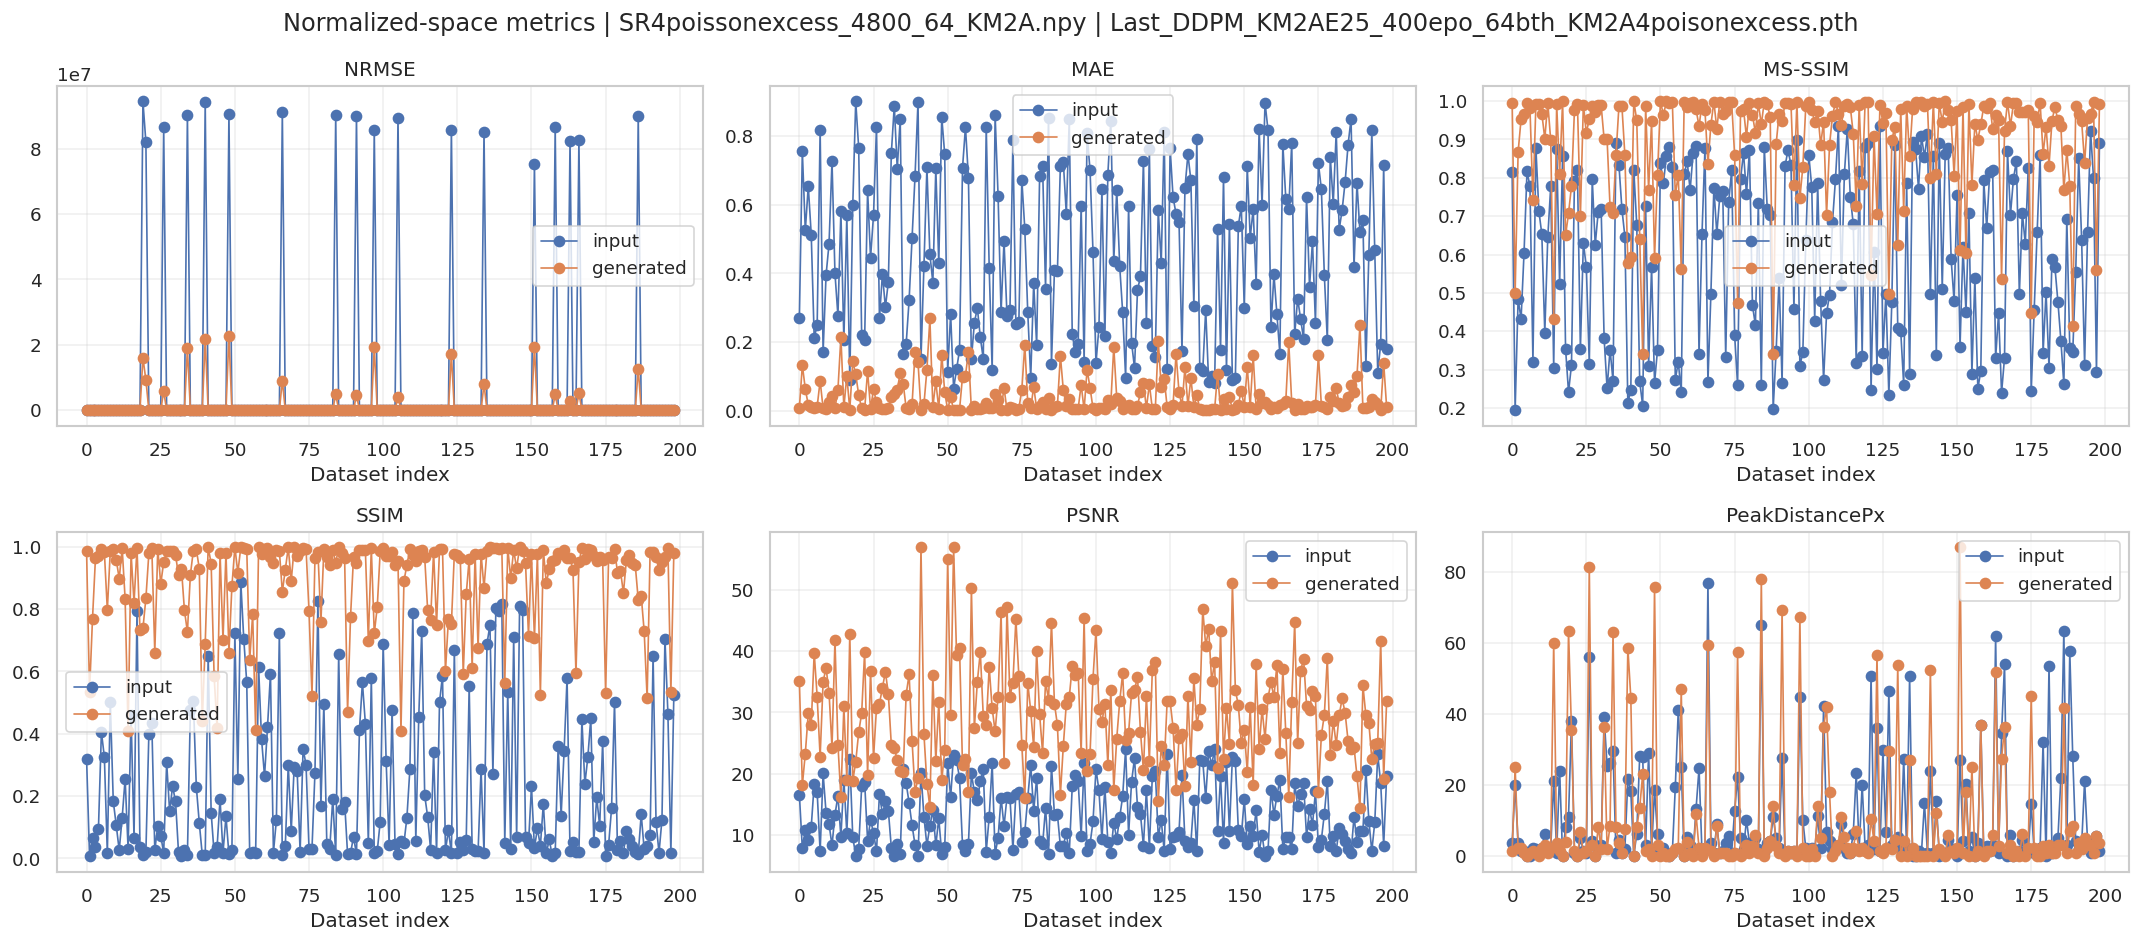

Saved metric plot: /root/LHAI_KM2A/saves/EVAL/DDPM/TRAIN/counts_metric_curves__SR4poissonexcess_4800_64_KM2A__Last_DDPM_KM2AE25_400epo_64bth_KM2A4poisonexcess.png


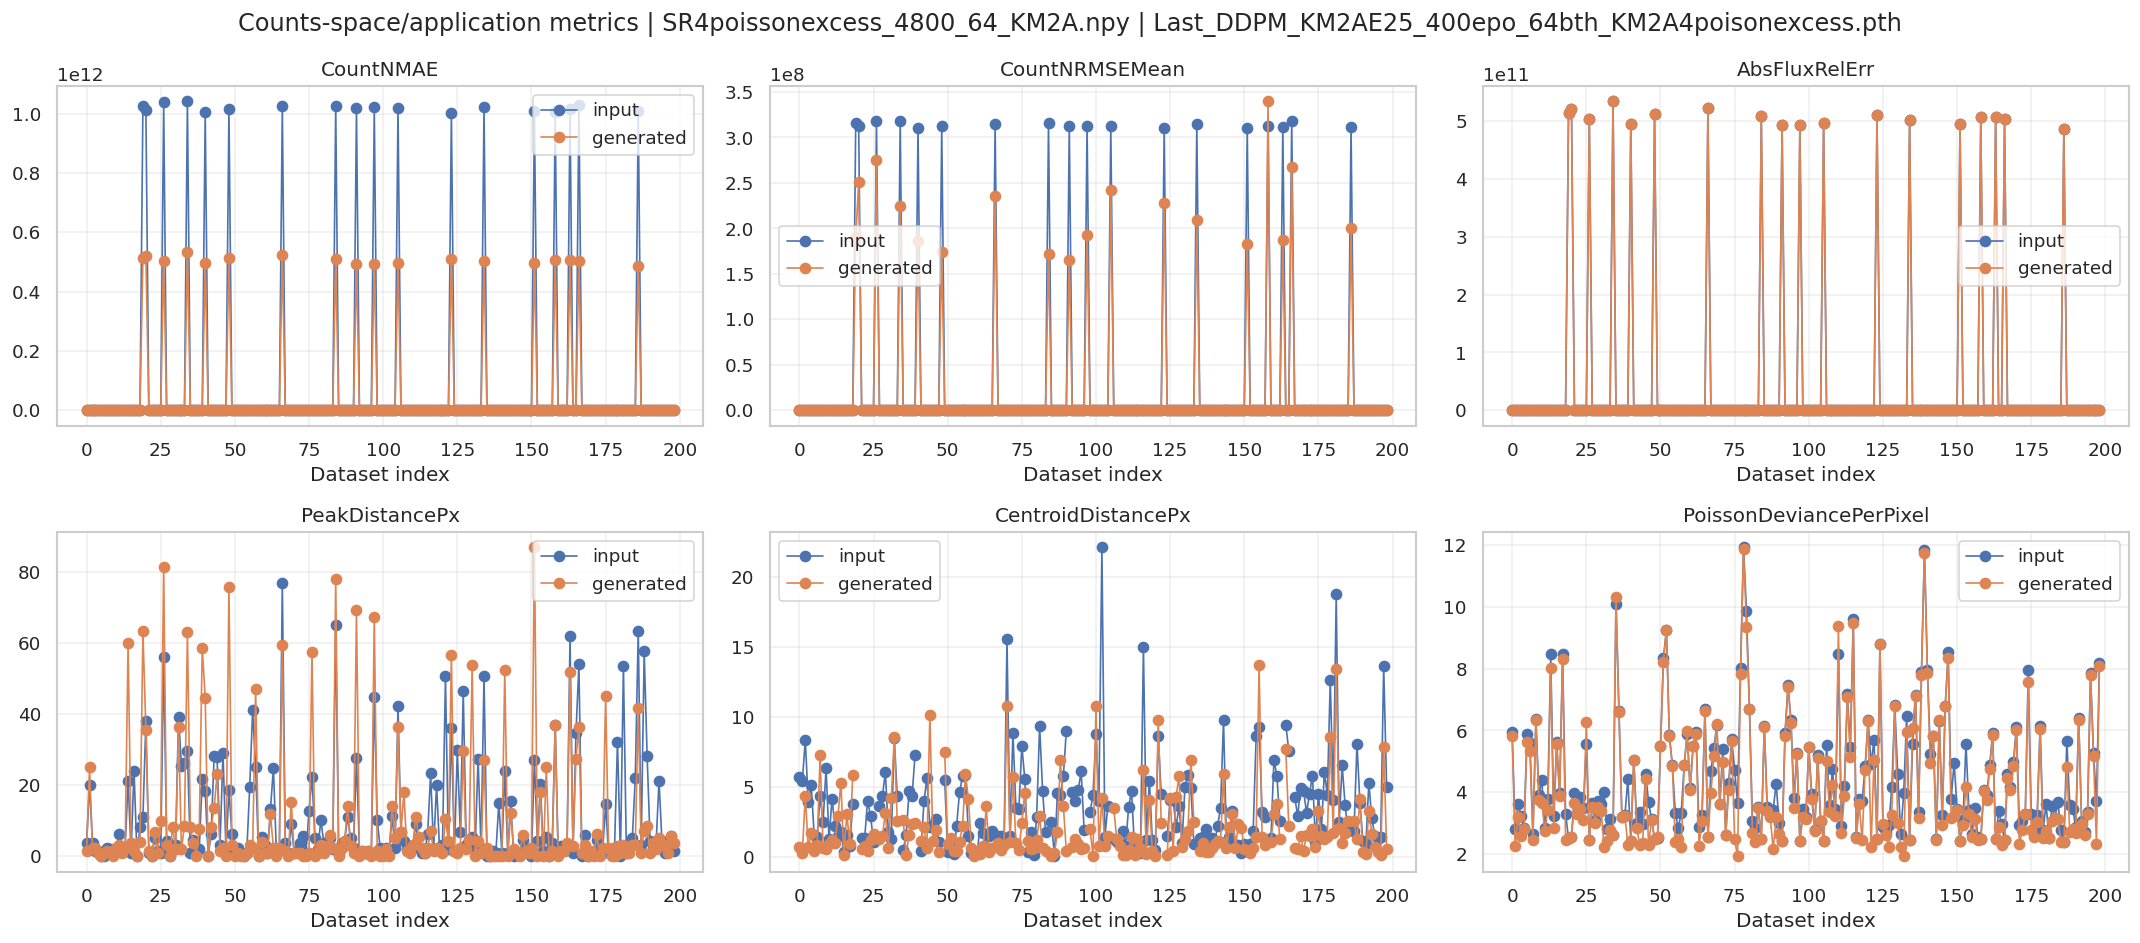

In [7]:
indices = select_eval_indices(
    total=inputs_np.shape[0],
    explicit=EVAL_INDICES,
    start=EVAL_START,
    stop=EVAL_STOP,
    step=EVAL_STEP,
)

normalized_rows, counts_rows, generated_cache = run_evaluations(indices)
normalized_summary = summarize_rows(normalized_rows)
counts_summary = summarize_rows(counts_rows)

print_normalized_summary(normalized_summary, n_images=len(indices))
print_counts_summary(counts_summary, n_images=len(indices))

if SAVE_OUTPUTS:
    save_evaluation_outputs(normalized_rows, counts_rows, normalized_summary, counts_summary, indices)

plot_metric_curves(
    normalized_rows,
    indices,
    metrics=["NRMSE", "MAE", "MS-SSIM", "SSIM", "PSNR", "PeakDistancePx"],
    title="Normalized-space metrics",
    filename_prefix="normalized_metric_curves",
)
plot_metric_curves(
    counts_rows,
    indices,
    metrics=["CountNMAE", "CountNRMSEMean", "AbsFluxRelErr", "PeakDistancePx", "CentroidDistancePx", "PoissonDeviancePerPixel"],
    title="Counts-space/application metrics",
    filename_prefix="counts_metric_curves",
)


In [8]:
def get_display_limits(image, floor_percentile=50, ceil_percentile=99.7):
    positive = image[image > 0]
    if positive.size == 0:
        return 0.0, 1.0
    vmin = float(np.percentile(positive, floor_percentile))
    vmax = float(np.percentile(positive, ceil_percentile))
    if vmax <= vmin:
        vmax = float(positive.max())
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return vmin, vmax


def get_contour_levels(image, contour_percentiles=(70, 82, 90, 96)):
    positive = image[image > 0]
    if positive.size == 0:
        return []
    levels = np.percentile(positive, contour_percentiles)
    levels = np.unique(levels[levels > 0])
    if levels.size < 2:
        return []
    return levels


def imshow_enhanced(ax, image, title, cmap="turbo", gamma=0.55, contour=True):
    vmin, vmax = get_display_limits(image)
    im = ax.imshow(
        image,
        origin="lower",
        cmap=cmap,
        norm=PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax),
        interpolation="nearest",
    )
    if contour:
        levels = get_contour_levels(image)
        if len(levels) > 0:
            ax.contour(image, levels=levels, origin="lower", colors="#8fd3ff", linewidths=0.45, alpha=0.85)
    ax.set_title(title)
    ax.axis("off")
    return im


def imshow_plain(ax, image, title, cmap="hot"):
    im = ax.imshow(image, origin="lower", cmap=cmap, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
    return im


def image2d(array):
    return np.asarray(array).squeeze()


def auto_line_segment(target):
    h, w = target.shape
    y0, x0 = np.unravel_index(int(np.nanargmax(target)), target.shape)
    half = max(4, min(h, w) // 4)
    x1 = max(0, x0 - half)
    x2 = min(w - 1, x0 + half)
    y1 = y0
    y2 = y0
    return x1, y1, x2, y2


def line_profile(image, segment, samples=160):
    x1, y1, x2, y2 = segment
    xs = np.linspace(x1, x2, samples)
    ys = np.linspace(y1, y2, samples)
    return map_coordinates(image, [ys, xs], order=1, mode="nearest")


@torch.no_grad()
def generate_for_indices(vis_indices):
    vis_indices = np.asarray(vis_indices, dtype=int)
    result = {}
    for batch_start in range(0, len(vis_indices), INFERENCE_BATCH_SIZE):
        batch_indices = vis_indices[batch_start : batch_start + INFERENCE_BATCH_SIZE]
        missing = [int(i) for i in batch_indices if int(i) not in generated_cache]
        if missing:
            inputs = tensor_from_numpy_batch(inputs_np, missing)
            generated = generate_batch(inputs).detach().cpu().numpy()
            for image_index, generated_image in zip(missing, generated):
                generated_cache[int(image_index)] = generated_image
        for image_index in batch_indices:
            result[int(image_index)] = generated_cache[int(image_index)]
    return result


def counts_triplet(image_index):
    input_img = raw_input_counts([image_index])[0]
    target_img = raw_target_counts([image_index])[0]
    output_norm = generate_for_indices([image_index])[int(image_index)][None, ...]
    output_img = restore_generated_counts(output_norm, [image_index], COUNTS_RESTORE_MODE_FOR_VISUAL)[0]
    return image2d(input_img), image2d(output_img), image2d(target_img)


def visualize_indices(vis_indices, mode="enhanced", save_name=None):
    vis_indices = [int(i) for i in vis_indices]
    n = len(vis_indices)
    fig, axes = plt.subplots(n, 6, figsize=(21, 3.4 * n), squeeze=False)
    for row_i, image_index in enumerate(vis_indices):
        input_img, output_img, target_img = counts_triplet(image_index)
        segment = LINE_SEGMENTS.get(image_index, auto_line_segment(target_img))
        plotter = imshow_enhanced if mode == "enhanced" else imshow_plain
        plotter(axes[row_i, 0], input_img, f"#{image_index} input counts")
        plotter(axes[row_i, 1], output_img, "DDPM counts")
        plotter(axes[row_i, 2], target_img, "GT counts")

        profile_axes = []
        for ax in axes[row_i, :3]:
            x1, y1, x2, y2 = segment
            ax.plot([x1, x2], [y1, y2], linestyle="--", color="white", linewidth=1.4)
            axins = inset_axes(ax, width="26%", height="26%", loc=4)
            axins.axis("off")
            axins.patch.set_alpha(0)
            profile_axes.append(axins)
        for axins, image, color in zip(profile_axes, [input_img, output_img, target_img], ["red", "dodgerblue", "black"]):
            axins.plot(line_profile(image, segment), color=color, linewidth=1.0)

        res_input = input_img - target_img
        res_output = output_img - target_img
        vmax = np.nanmax(np.abs([res_input, res_output]))
        vmax = float(vmax if vmax > 0 else 1e-6)
        im3 = axes[row_i, 3].imshow(res_input, origin="lower", cmap="coolwarm", vmin=-vmax, vmax=vmax)
        axes[row_i, 3].set_title("input - GT counts")
        axes[row_i, 3].axis("off")
        fig.colorbar(im3, ax=axes[row_i, 3], fraction=0.046, pad=0.04)
        im4 = axes[row_i, 4].imshow(res_output, origin="lower", cmap="coolwarm", vmin=-vmax, vmax=vmax)
        axes[row_i, 4].set_title("output - GT counts")
        axes[row_i, 4].axis("off")
        fig.colorbar(im4, ax=axes[row_i, 4], fraction=0.046, pad=0.04)
        axes[row_i, 5].plot(line_profile(input_img, segment), color="red", label="input")
        axes[row_i, 5].plot(line_profile(output_img, segment), color="dodgerblue", label="output")
        axes[row_i, 5].plot(line_profile(target_img, segment), color="black", label="GT")
        axes[row_i, 5].set_title("counts line profile")
        axes[row_i, 5].legend(fontsize=8)
        axes[row_i, 5].grid(True, alpha=0.3)
    fig.suptitle(
        f"{mode} counts-space DDPM comparison | visual restore={COUNTS_RESTORE_MODE_FOR_VISUAL} | {DATA_NAME} | {MODEL_WEIGHT_NAME}",
        y=1.002,
    )
    fig.tight_layout()
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        save_name = save_name or f"visual_{mode}_counts__{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}.png"
        fig_path = OUTPUT_DIR / save_name
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved visualization: {fig_path}")
    plt.show()


def show_channel_batch(kind="target", count=32, columns=8, random=True, seed=0, mode="enhanced"):
    rng = np.random.default_rng(seed)
    count = min(count, raw_inputs_np.shape[0])
    indices = np.sort(rng.choice(raw_inputs_np.shape[0], size=count, replace=False)) if random else np.arange(count)
    rows_count = math.ceil(len(indices) / columns)
    fig, axes = plt.subplots(rows_count, columns, figsize=(columns * 1.8, rows_count * 1.8), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, idx in zip(axes.ravel(), indices):
        if kind == "input":
            image = image2d(raw_input_counts([idx])[0])
        elif kind == "target":
            image = image2d(raw_target_counts([idx])[0])
        else:
            raise ValueError("kind must be 'input' or 'target'")
        if mode == "enhanced":
            imshow_enhanced(ax, image, f"#{idx}")
        else:
            imshow_plain(ax, image, f"#{idx}")
    fig.suptitle(f"{mode} counts batch view | {kind} | {DATA_NAME}", y=1.01)
    fig.tight_layout()
    plt.show()


/tmp/ipykernel_10511/3256862737.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved visualization: /root/LHAI_KM2A/saves/EVAL/DDPM/TRAIN/visual_plain_counts__SR4poissonexcess_4800_64_KM2A__Last_DDPM_KM2AE25_400epo_64bth_KM2A4poisonexcess.png


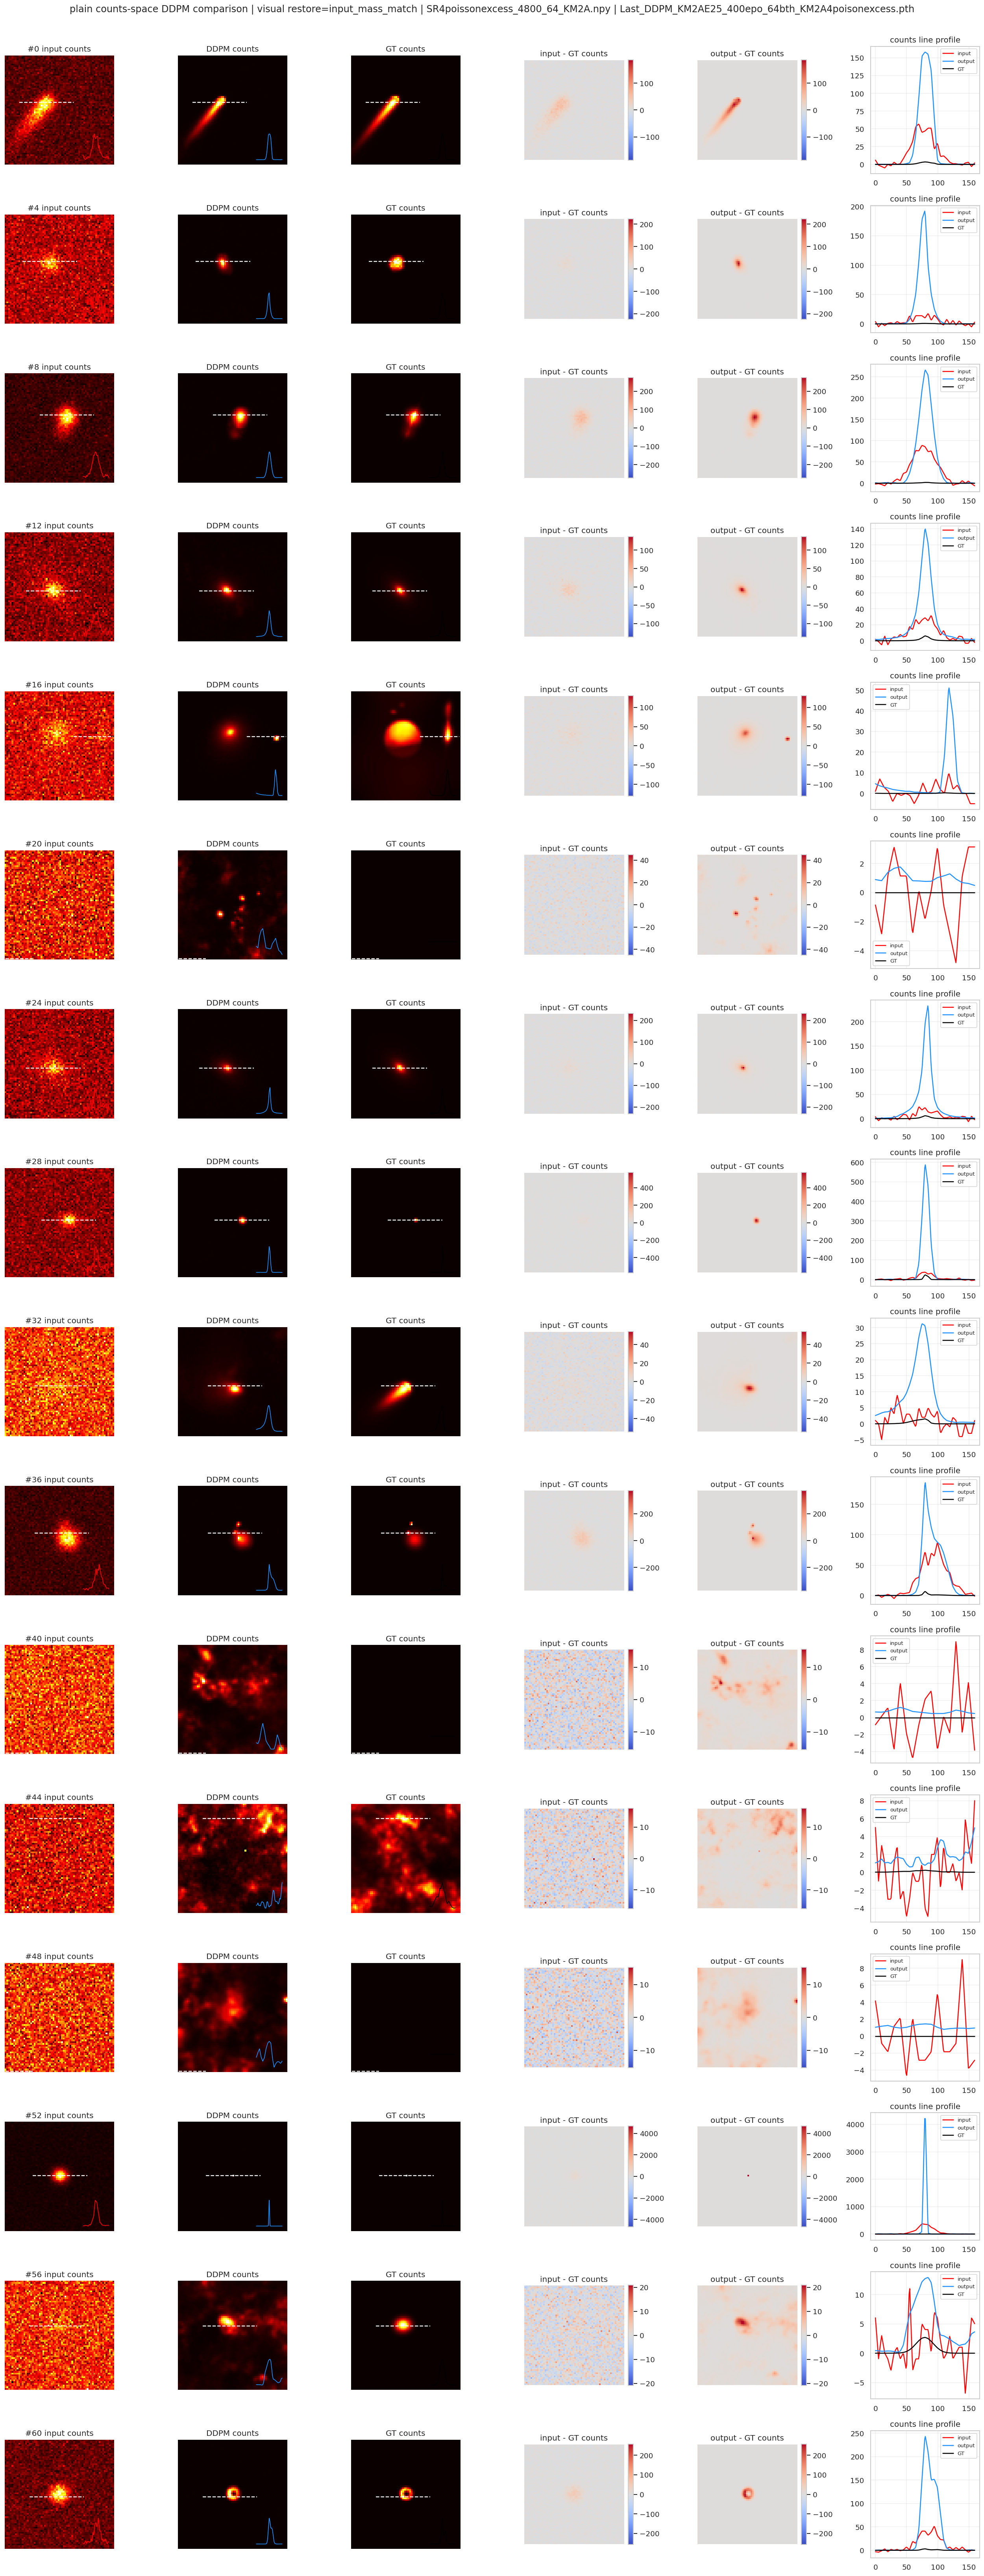

Saved visualization: /root/LHAI_KM2A/saves/EVAL/DDPM/TRAIN/visual_enhanced_counts__SR4poissonexcess_4800_64_KM2A__Last_DDPM_KM2AE25_400epo_64bth_KM2A4poisonexcess.png


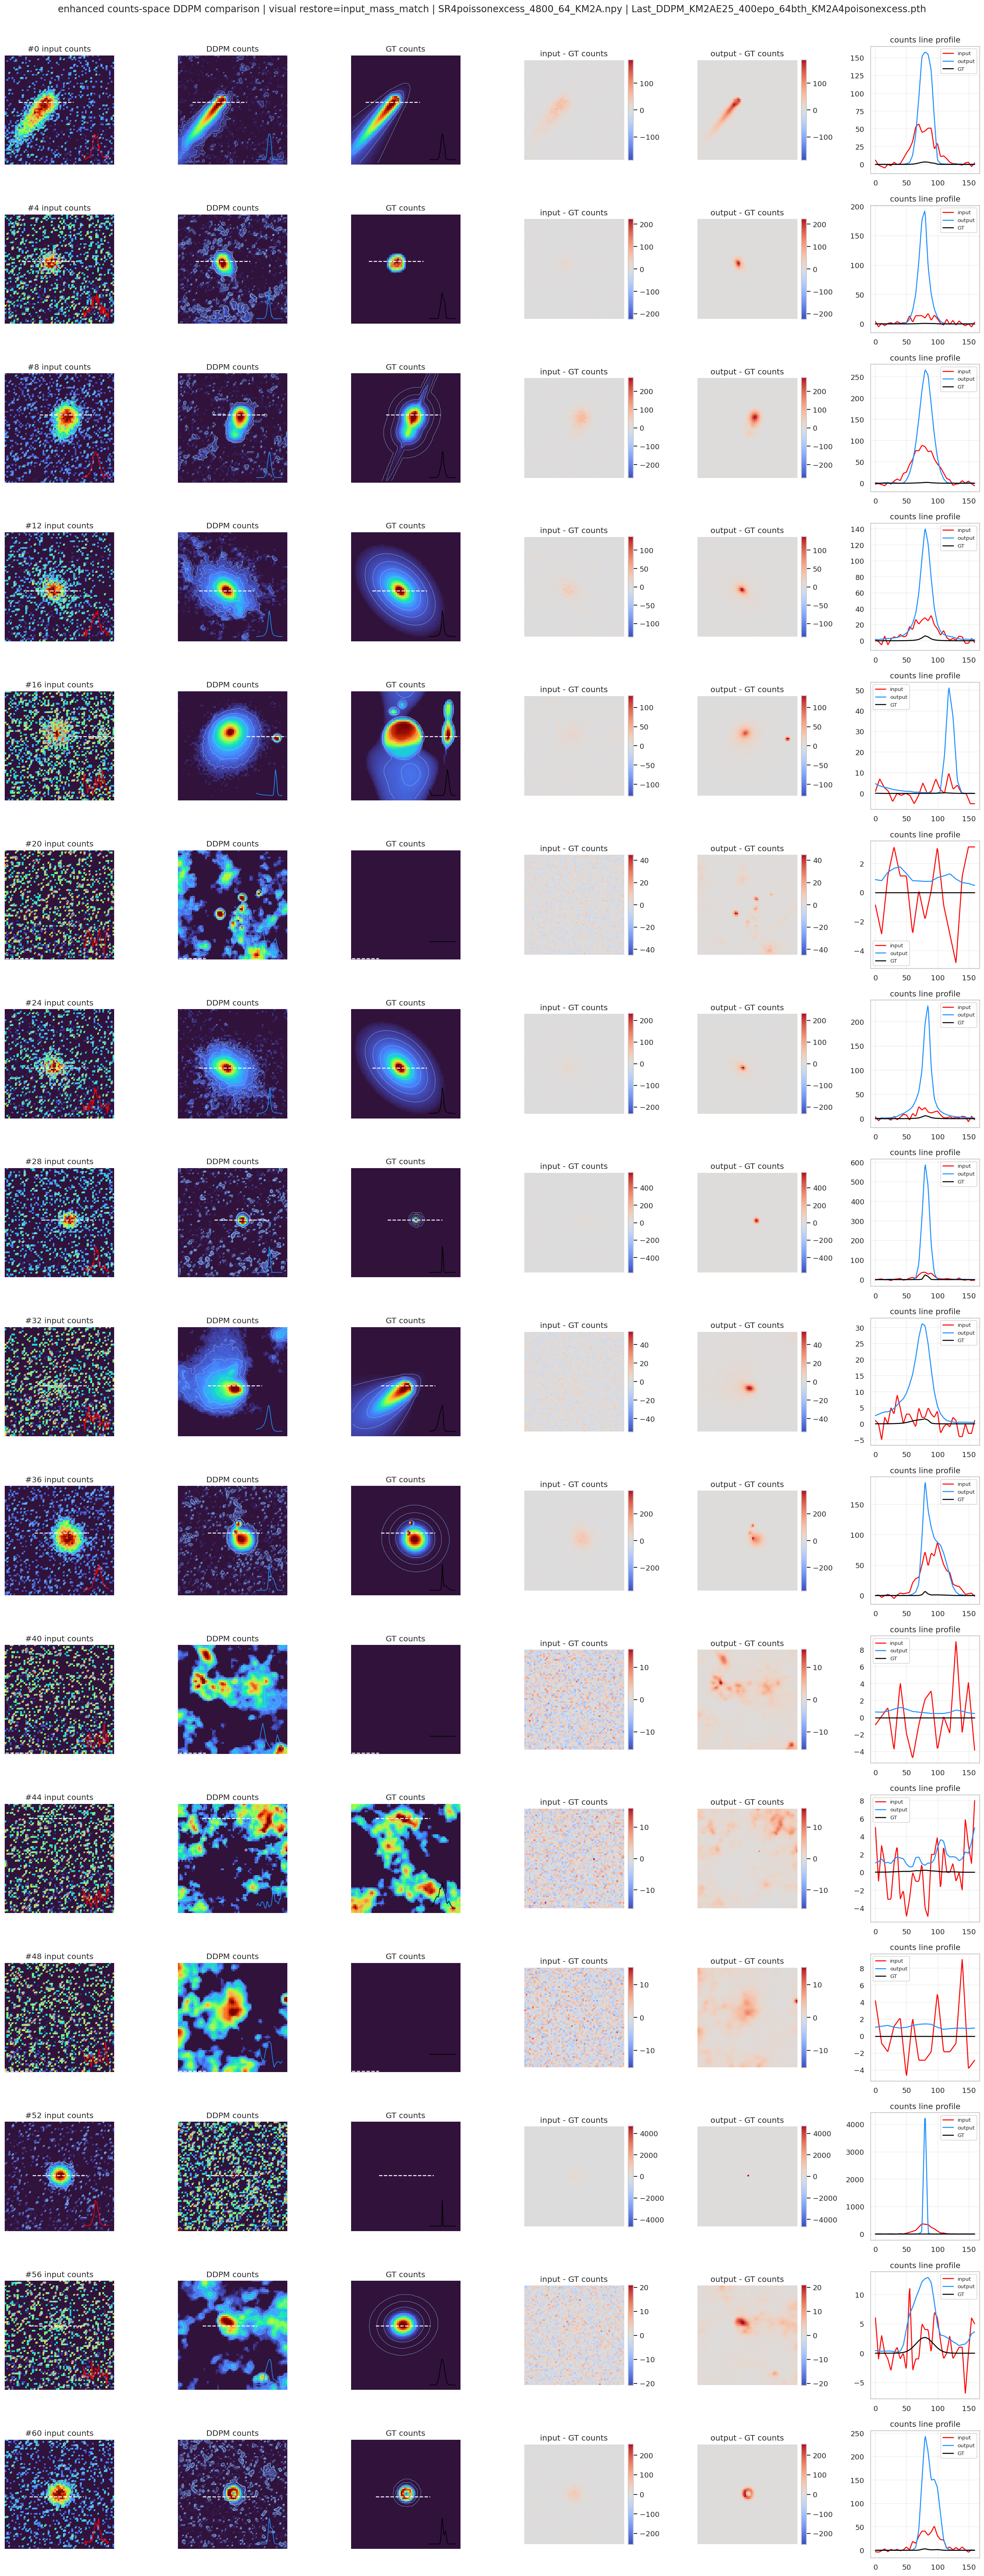

In [9]:
visualize_indices(VIS_INDICES, mode="plain")
visualize_indices(VIS_INDICES, mode="enhanced")


Saved summary bar plot: /root/LHAI_KM2A/saves/EVAL/DDPM/TRAIN/normalized_summary_bars__SR4poissonexcess_4800_64_KM2A__Last_DDPM_KM2AE25_400epo_64bth_KM2A4poisonexcess.png


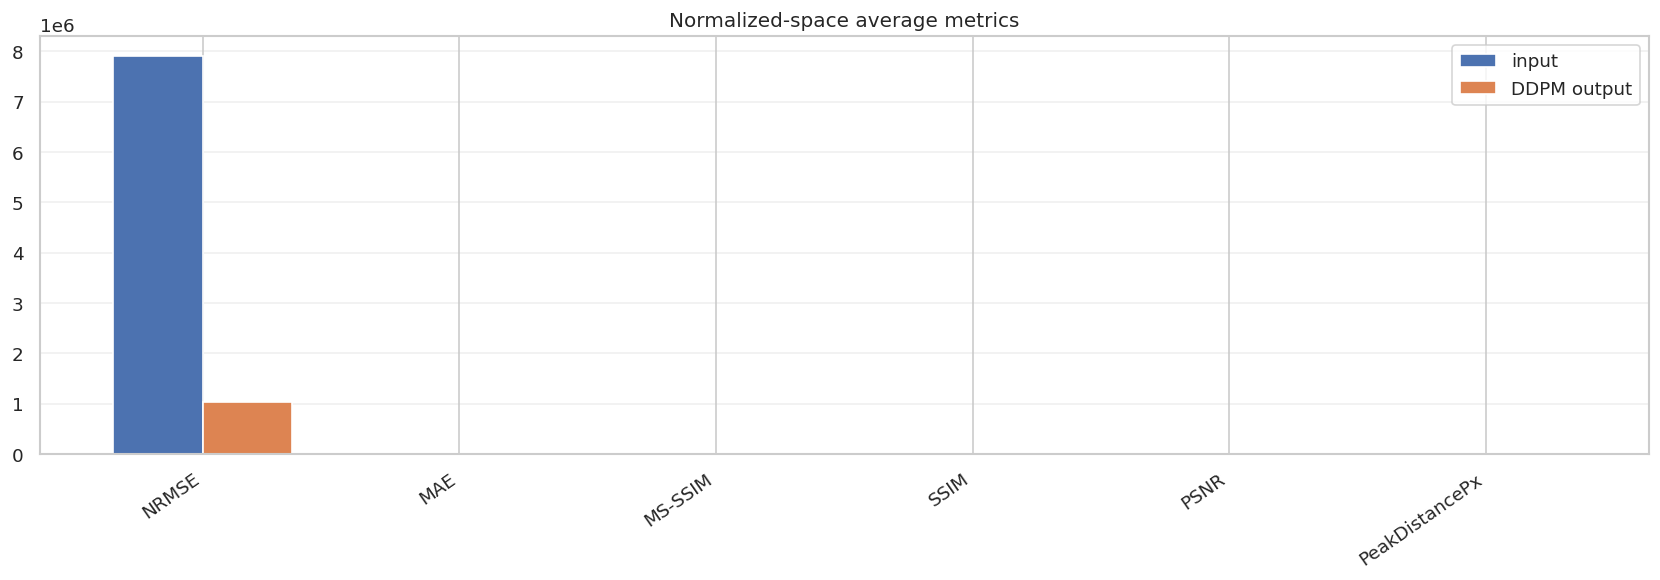

Saved summary bar plot: /root/LHAI_KM2A/saves/EVAL/DDPM/TRAIN/counts_summary_bars__SR4poissonexcess_4800_64_KM2A__Last_DDPM_KM2AE25_400epo_64bth_KM2A4poisonexcess.png


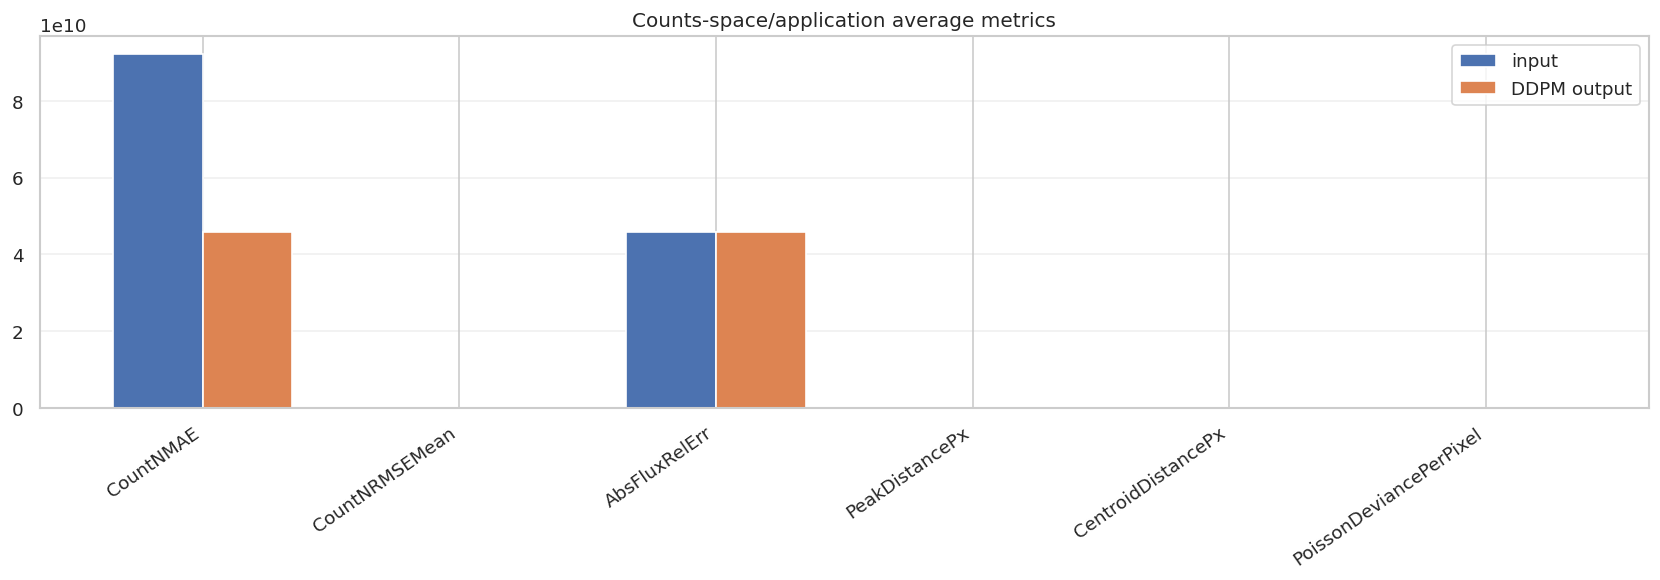

Saved residual histogram: /root/LHAI_KM2A/saves/EVAL/DDPM/TRAIN/counts_residual_hist__SR4poissonexcess_4800_64_KM2A__Last_DDPM_KM2AE25_400epo_64bth_KM2A4poisonexcess.png


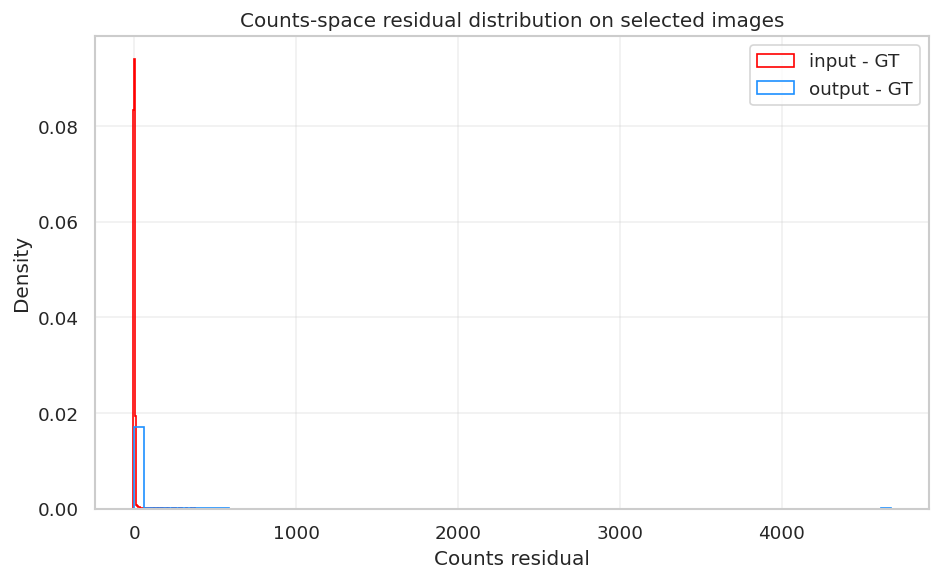

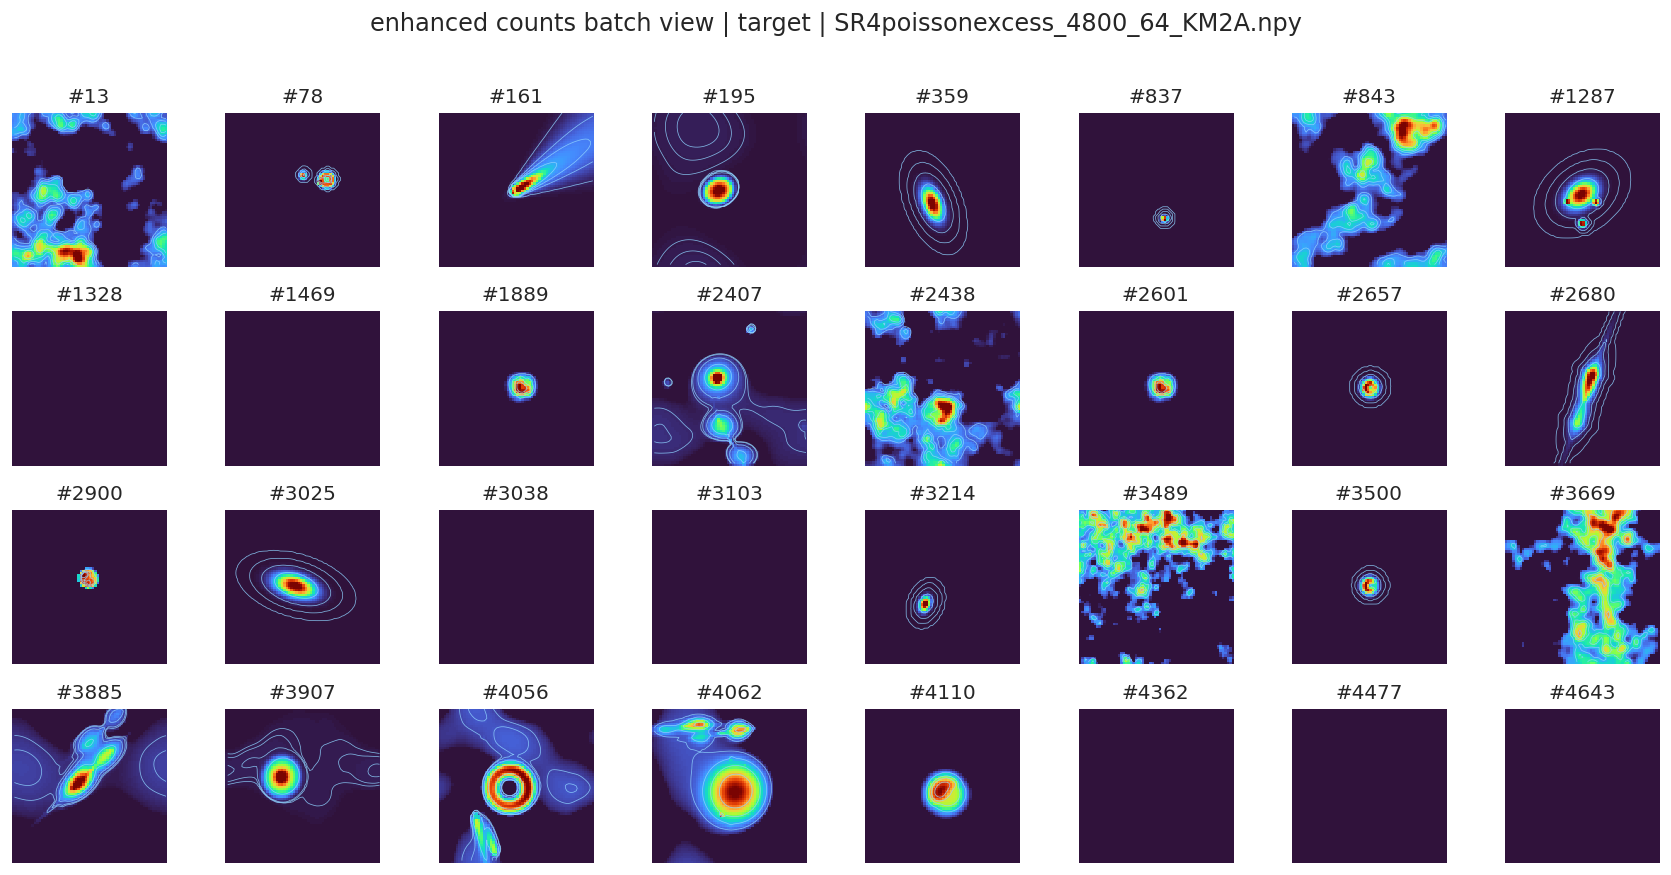

In [10]:
def plot_summary_bars(summary, metrics, title, filename_prefix):
    x = np.arange(len(metrics))
    width = 0.35
    input_means = [summary["input"][m]["mean"] for m in metrics]
    output_means = [summary["generated"][m]["mean"] for m in metrics]
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - width / 2, input_means, width, label="input")
    ax.bar(x + width / 2, output_means, width, label="DDPM output")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=35, ha="right")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    if SAVE_OUTPUTS:
        fig_path = OUTPUT_DIR / f"{filename_prefix}__{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved summary bar plot: {fig_path}")
    plt.show()


def plot_counts_residual_histograms(vis_indices):
    input_residuals = []
    output_residuals = []
    for image_index in vis_indices:
        input_img, output_img, target_img = counts_triplet(int(image_index))
        input_residuals.append((input_img - target_img).reshape(-1))
        output_residuals.append((output_img - target_img).reshape(-1))
    input_residuals = np.concatenate(input_residuals)
    output_residuals = np.concatenate(output_residuals)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(input_residuals, bins=80, histtype="step", density=True, label="input - GT", color="red")
    ax.hist(output_residuals, bins=80, histtype="step", density=True, label="output - GT", color="dodgerblue")
    ax.set_title("Counts-space residual distribution on selected images")
    ax.set_xlabel("Counts residual")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if SAVE_OUTPUTS:
        fig_path = OUTPUT_DIR / f"counts_residual_hist__{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved residual histogram: {fig_path}")
    plt.show()


plot_summary_bars(
    normalized_summary,
    metrics=["NRMSE", "MAE", "MS-SSIM", "SSIM", "PSNR", "PeakDistancePx"],
    title="Normalized-space average metrics",
    filename_prefix="normalized_summary_bars",
)
plot_summary_bars(
    counts_summary,
    metrics=["CountNMAE", "CountNRMSEMean", "AbsFluxRelErr", "PeakDistancePx", "CentroidDistancePx", "PoissonDeviancePerPixel"],
    title="Counts-space/application average metrics",
    filename_prefix="counts_summary_bars",
)
plot_counts_residual_histograms(VIS_INDICES)
show_channel_batch(kind="target", count=32, columns=8, random=True, seed=SAMPLING_SEED, mode="enhanced")
